In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
TRAIN_PATH = (
    Path("..")
    / "data"
    / "processed"
    / "train_windows.parquet"
)

TEST_PATH = (
    Path("..")
    / "data"
    / "processed"
    / "test_windows.parquet"
)

train_df = pd.read_parquet(TRAIN_PATH)
test_df = pd.read_parquet(TEST_PATH)

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

Training rows: 7335
Testing rows: 1577


In [3]:
columns_not_used_for_model = [
    "participant_id",
    "recording_id",
    "window_number",
    "start_time_ms",
    "end_time_ms",
    "fog"
]

feature_columns = [
    column
    for column in train_df.columns
    if column not in columns_not_used_for_model
]

X_train = train_df[feature_columns]
y_train = train_df["fog"]

X_test = test_df[feature_columns]
y_test = test_df["fog"]

print("Number of features:", len(feature_columns))

Number of features: 45


In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

logistic_predictions = logistic_model.predict(
    X_test_scaled
)

In [6]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

random_forest_model.fit(
    X_train,
    y_train
)

random_forest_predictions = random_forest_model.predict(
    X_test
)

In [7]:
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced"
)

svm_model.fit(
    X_train_scaled,
    y_train
)

svm_predictions = svm_model.predict(
    X_test_scaled
)

In [8]:
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gradient_boosting_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

gradient_boosting_predictions = gradient_boosting_model.predict(
    X_test
)

In [9]:
results = pd.DataFrame({
    "model": [
        "Logistic Regression",
        "Random Forest",
        "SVM",
        "Gradient Boosting"
    ],
    "accuracy": [
        accuracy_score(y_test, logistic_predictions),
        accuracy_score(y_test, random_forest_predictions),
        accuracy_score(y_test, svm_predictions),
        accuracy_score(y_test, gradient_boosting_predictions)
    ],
    "precision": [
        precision_score(y_test, logistic_predictions, zero_division=0),
        precision_score(y_test, random_forest_predictions, zero_division=0),
        precision_score(y_test, svm_predictions, zero_division=0),
        precision_score(y_test, gradient_boosting_predictions, zero_division=0)
    ],
    "recall": [
        recall_score(y_test, logistic_predictions, zero_division=0),
        recall_score(y_test, random_forest_predictions, zero_division=0),
        recall_score(y_test, svm_predictions, zero_division=0),
        recall_score(y_test, gradient_boosting_predictions, zero_division=0)
    ],
    "f1_score": [
        f1_score(y_test, logistic_predictions, zero_division=0),
        f1_score(y_test, random_forest_predictions, zero_division=0),
        f1_score(y_test, svm_predictions, zero_division=0),
        f1_score(y_test, gradient_boosting_predictions, zero_division=0)
    ]
})

results.round(3)

,model,accuracy,precision,recall,f1_score
0,Logistic Regression,0.879,0.573,0.545,0.559
1,Random Forest,0.862,0.667,0.036,0.068
2,SVM,0.869,0.527,0.658,0.585
3,Gradient Boosting,0.884,0.580,0.640,0.608


In [10]:
results.sort_values(
    by="f1_score",
    ascending=False
).round(3)

,model,accuracy,precision,recall,f1_score
3,Gradient Boosting,0.884,0.580,0.640,0.608
2,SVM,0.869,0.527,0.658,0.585
0,Logistic Regression,0.879,0.573,0.545,0.559
1,Random Forest,0.862,0.667,0.036,0.068


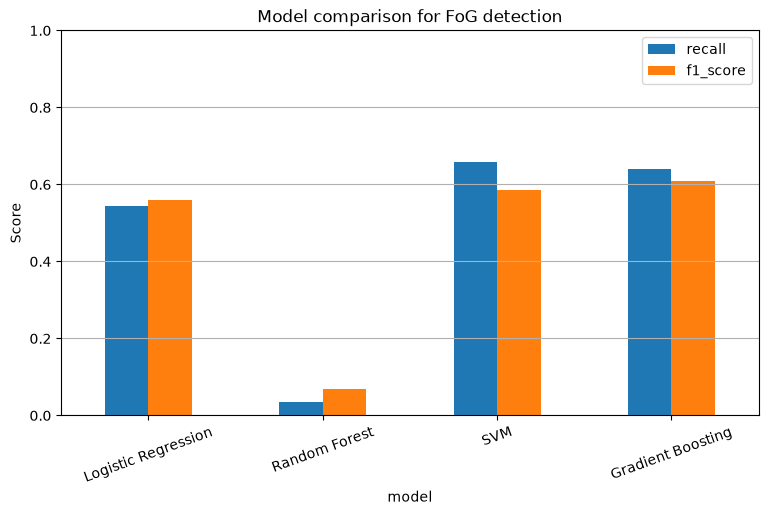

In [11]:
results.plot(
    x="model",
    y=["recall", "f1_score"],
    kind="bar",
    figsize=(9, 5)
)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Model comparison for FoG detection")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

### Model comparison conclusion

Gradient Boosting was selected as the final model because it achieved the highest F1-score. It provides the best balance between detecting FoG windows and avoiding false alarms.

SVM achieved slightly higher recall, but its precision and F1-score were lower. Random Forest achieved reasonable accuracy but detected very few FoG windows, making it unsuitable for this task.

The model comparison is based on a participant-level test split, so participants in the test set were not seen during training.